# Linear Model Analysis for Post Divergence Dataset

This notebook performs linear regression analysis on the post divergence dataset to understand factors influencing divergence scores.

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 1. Load and Explore Data

In [3]:
# Load the JSON data
with open('post_divergence_dataset.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

df.head()

,post_id,gender1,gender2,stance1,stance2,post_likes,post_comments,post_timestamp,verified,divergence
0,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Female,Neutral,ProChoice,247,29,2020-04-02T14:22:29.000Z,True,0.0
1,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Female,Neutral,ProLife,247,29,2020-04-02T14:22:29.000Z,True,0.0
2,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Male,Neutral,Neutral,247,29,2020-04-02T14:22:29.000Z,True,0.0
3,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Male,Neutral,ProChoice,247,29,2020-04-02T14:22:29.000Z,True,0.0
4,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Male,Neutral,ProLife,247,29,2020-04-02T14:22:29.000Z,True,0.0


In [4]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
post_id               str
gender1               str
gender2               str
stance1               str
stance2               str
post_likes          int64
post_comments       int64
post_timestamp        str
verified             bool
divergence        float64
dtype: object

Missing Values:
post_id           0
gender1           0
gender2           0
stance1           0
stance2           0
post_likes        0
post_comments     0
post_timestamp    0
verified          0
divergence        0
dtype: int64


In [5]:
df.describe()

,post_likes,post_comments,divergence
count,9180.000000,9180.000000,9180.000000
mean,9349.569826,357.330392,0.187983
std,41067.982719,928.233688,0.249522
min,6.000000,2.000000,0.000000
25%,259.000000,12.000000,0.000000
50%,866.000000,53.000000,0.000000
75%,5200.000000,280.000000,0.400000
max,761600.000000,9200.000000,1.000000


In [6]:
# Unique values for categorical columns
categorical_cols = ['gender1', 'gender2', 'stance1', 'stance2']
for col in categorical_cols:
    print(f"\n{col} unique values:", df[col].unique())


gender1 unique values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str

gender2 unique values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str

stance1 unique values: <StringArray>
['Neutral', 'ProChoice', 'ProLife']
Length: 3, dtype: str

stance2 unique values: <StringArray>
['ProChoice', 'ProLife', 'Neutral']
Length: 3, dtype: str


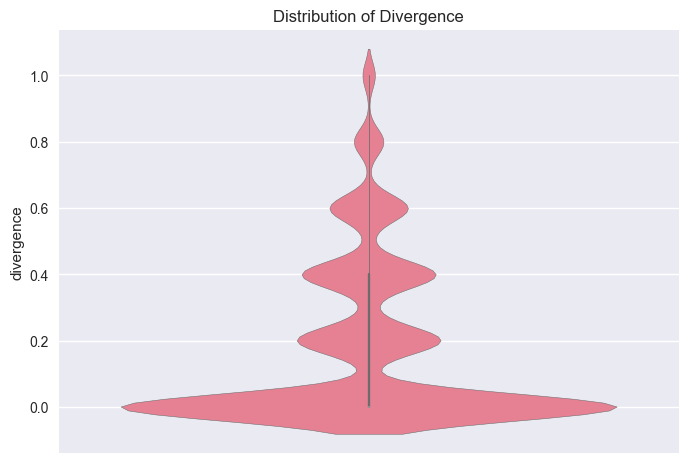

In [7]:
sns.violinplot(y=df['divergence'])
plt.title('Distribution of Divergence')
plt.show()

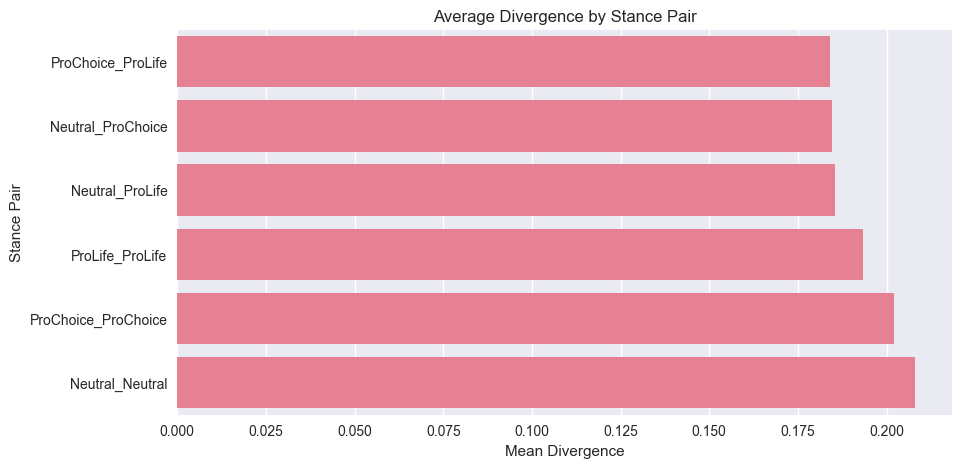

In [8]:
# Create non-directional stance pair
df['stance_pair'] = df.apply(
    lambda row: "_".join(sorted([row['stance1'], row['stance2']])),
    axis=1
)

# Calculate average divergence per stance pair
stance_mean = (
    df.groupby('stance_pair')['divergence']
    .mean()
    .sort_values()
)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    x=stance_mean.values,
    y=stance_mean.index
)

plt.title('Average Divergence by Stance Pair')
plt.xlabel('Mean Divergence')
plt.ylabel('Stance Pair')

plt.show()

## 2. Data Preprocessing

In [9]:

# ---------------------------
# 1. Time feature
# ---------------------------
df['post_timestamp'] = pd.to_datetime(df['post_timestamp'])

df['months_since_post'] = (
    (pd.Timestamp.now(tz='UTC') - df['post_timestamp']).dt.days / 30
)


# ---------------------------
# 2. Interaction features
# ---------------------------
# Same gender or not
df['gender_match'] = (
    df['gender1'] == df['gender2']
).astype(int)

# Stance relationship
df['stance_pair'] = (
    df['stance1'] + "_" + df['stance2']
)


# ---------------------------
# 3. Log transform engagement
# ---------------------------
df['log_likes'] = np.log1p(df['post_likes'])
df['log_comments'] = np.log1p(df['post_comments'])


# ---------------------------
# 4. Verified encoding
# ---------------------------
df['verified_encoded'] = df['verified'].astype(int)


# ---------------------------
# 5. One-hot encode categorical feature
# ---------------------------
df = pd.get_dummies(
    df,
    columns=['stance_pair'],
    drop_first=True
)


# ---------------------------
# 6. Drop unnecessary columns
# ---------------------------
df = df.drop(
    columns=[
        'post_id',
        'post_timestamp',
        'gender1',
        'gender2',
        'stance1',
        'stance2',
        'verified'
    ]
)



df.head()

,post_likes,post_comments,divergence,months_since_post,gender_match,log_likes,log_comments,verified_encoded,stance_pair_Neutral_ProChoice,stance_pair_Neutral_ProLife,stance_pair_ProChoice_Neutral,stance_pair_ProChoice_ProChoice,stance_pair_ProChoice_ProLife,stance_pair_ProLife_Neutral,stance_pair_ProLife_ProChoice,stance_pair_ProLife_ProLife
0,247,29,0.0,77.033333,1,5.513429,3.401197,1,True,False,False,False,False,False,False,False
1,247,29,0.0,77.033333,1,5.513429,3.401197,1,False,True,False,False,False,False,False,False
2,247,29,0.0,77.033333,0,5.513429,3.401197,1,False,False,False,False,False,False,False,False
3,247,29,0.0,77.033333,0,5.513429,3.401197,1,True,False,False,False,False,False,False,False
4,247,29,0.0,77.033333,0,5.513429,3.401197,1,False,True,False,False,False,False,False,False


## 3. Linear Model Building

In [10]:
# Define features for linear model

feature_cols = [
    'log_likes',
    'log_comments',
    'verified_encoded',
    'gender_match',
    'months_since_post'
]

# Add one-hot stance pair features
feature_cols += [
    col for col in df.columns 
    if col.startswith('stance_pair_')
]

X = df[feature_cols]
y = df['divergence']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (9180, 13)
Target vector shape: (9180,)


In [11]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 7344
Testing set size: 1836


In [12]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")

Features scaled successfully


### 3.1 Basic Linear Regression

In [15]:
# Train basic linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# Evaluate model
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Linear Regression Results:")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")
print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training MAE: {train_mae:.4f}")
print(f"Testing MAE: {test_mae:.4f}")

Linear Regression Results:
Training R²: 0.3415
Testing R²: 0.3472
Training MSE: 0.0409
Testing MSE: 0.0409
Training MAE: 0.1609
Testing MAE: 0.1599


In [16]:
# Feature coefficients
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients:")
print(coefficients)

print(f"\nIntercept: {lr_model.intercept_:.4f}")

Feature Coefficients:
                            Feature  Coefficient
4                 months_since_post    -0.096273
1                      log_comments     0.088854
0                         log_likes     0.015378
3                      gender_match    -0.012352
6       stance_pair_Neutral_ProLife    -0.006706
2                  verified_encoded    -0.005807
5     stance_pair_Neutral_ProChoice    -0.005026
12      stance_pair_ProLife_ProLife    -0.004280
9     stance_pair_ProChoice_ProLife    -0.003644
8   stance_pair_ProChoice_ProChoice    -0.001876
11    stance_pair_ProLife_ProChoice    -0.001688
7     stance_pair_ProChoice_Neutral    -0.001256
10      stance_pair_ProLife_Neutral    -0.000508

Intercept: 0.1878


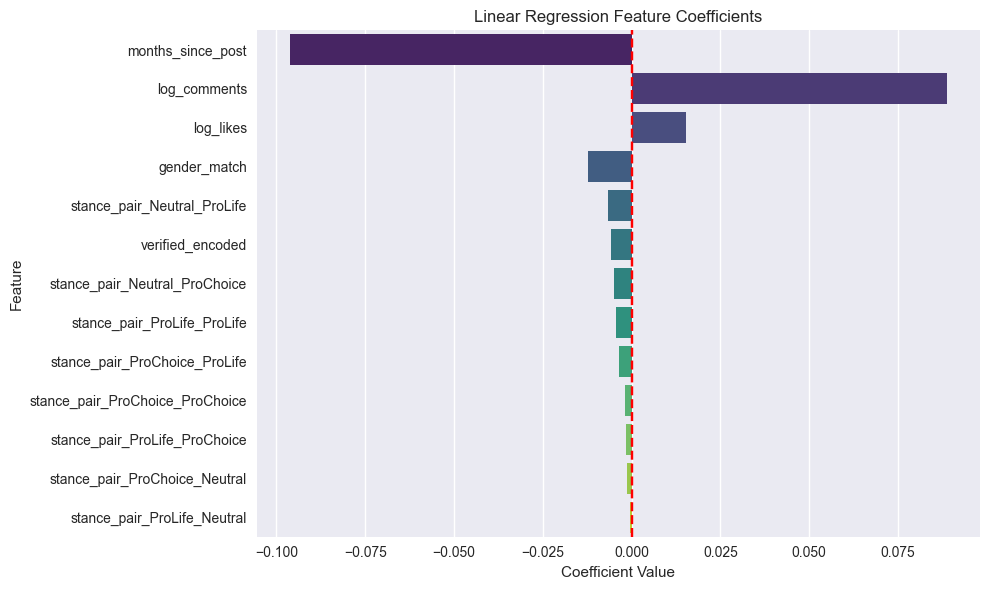

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    palette="viridis",
    dodge=False,
    legend=False
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(x=0, color="red", linestyle="--")
plt.tight_layout()
plt.show()

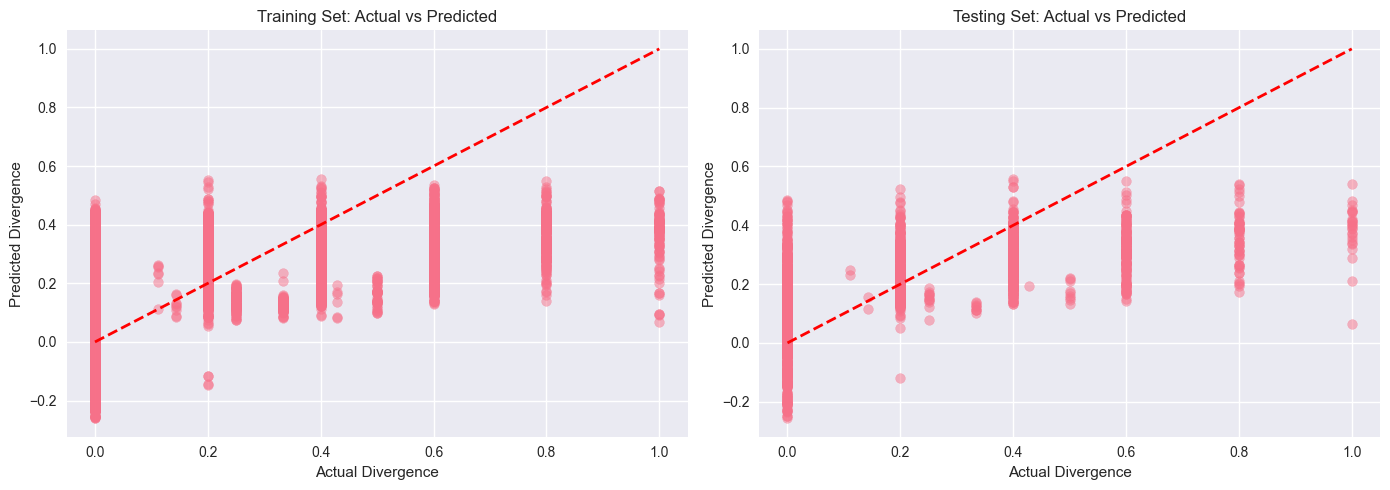

In [19]:
# Actual vs Predicted plot:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Divergence')
axes[0].set_ylabel('Predicted Divergence')
axes[0].set_title('Training Set: Actual vs Predicted')

axes[1].scatter(y_test, y_test_pred, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Divergence')
axes[1].set_ylabel('Predicted Divergence')
axes[1].set_title('Testing Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

### 4.2 Ridge Regression (L2 Regularization)

In [20]:
# Train Ridge regression with different alpha values
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2')
    ridge_scores.append({
        'alpha': alpha,
        'mean_r2': scores.mean(),
        'std_r2': scores.std()
    })

ridge_results = pd.DataFrame(ridge_scores)
print("Ridge Regression Cross-Validation Results:")
print(ridge_results)

Ridge Regression Cross-Validation Results:
    alpha   mean_r2    std_r2
0    0.01  0.338534  0.016094
1    0.10  0.338534  0.016094
2    1.00  0.338534  0.016092
3   10.00  0.338540  0.016071
4  100.00  0.338496  0.015861


In [21]:
# Train best Ridge model
best_alpha = ridge_results.loc[ridge_results['mean_r2'].idxmax(), 'alpha']
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train_scaled, y_train)

# Evaluate
y_test_pred_ridge = best_ridge.predict(X_test_scaled)
ridge_r2 = r2_score(y_test, y_test_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_test_pred_ridge)

print(f"Best Ridge Model (alpha={best_alpha}):")
print(f"R²: {ridge_r2:.4f}")
print(f"MSE: {ridge_mse:.4f}")

Best Ridge Model (alpha=10.0):
R²: 0.3471
MSE: 0.0409


### 4.3 Lasso Regression (L1 Regularization)

In [22]:
# Train Lasso regression with different alpha values
lasso_scores = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    scores = cross_val_score(lasso, X_train_scaled, y_train, cv=5, scoring='r2')
    lasso_scores.append({
        'alpha': alpha,
        'mean_r2': scores.mean(),
        'std_r2': scores.std()
    })

lasso_results = pd.DataFrame(lasso_scores)
print("Lasso Regression Cross-Validation Results:")
print(lasso_results)

Lasso Regression Cross-Validation Results:
    alpha   mean_r2    std_r2
0    0.01  0.334231  0.013392
1    0.10  0.039772  0.003677
2    1.00 -0.000783  0.000898
3   10.00 -0.000783  0.000898
4  100.00 -0.000783  0.000898


In [23]:
# Train best Lasso model
best_alpha_lasso = lasso_results.loc[lasso_results['mean_r2'].idxmax(), 'alpha']
best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)

# Evaluate
y_test_pred_lasso = best_lasso.predict(X_test_scaled)
lasso_r2 = r2_score(y_test, y_test_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_test_pred_lasso)

print(f"Best Lasso Model (alpha={best_alpha_lasso}):")
print(f"R²: {lasso_r2:.4f}")
print(f"MSE: {lasso_mse:.4f}")

# Feature selection (non-zero coefficients)
lasso_coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': best_lasso.coef_
})
print("\nLasso Feature Selection (non-zero coefficients):")
print(lasso_coefficients[lasso_coefficients['Coefficient'] != 0])

Best Lasso Model (alpha=0.01):
R²: 0.3419
MSE: 0.0412

Lasso Feature Selection (non-zero coefficients):
             Feature  Coefficient
0          log_likes     0.006347
1       log_comments     0.085943
3       gender_match    -0.004461
4  months_since_post    -0.086815


## 4. Statistical Analysis with Statsmodels

In [24]:
# Add constant for statsmodels
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Print summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             divergence   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     292.3
Date:                Fri, 31 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:58:48   Log-Likelihood:                 1314.2
No. Observations:                7344   AIC:                            -2600.
Df Residuals:                    7330   BIC:                            -2504.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1878      0.002     79.473      0.0

In [25]:
# Extract p-values and significance
results_df = pd.DataFrame({
    'Feature': ['Intercept'] + feature_cols,
    'Coefficient': ols_model.params,
    'Std Error': ols_model.bse,
    't-value': ols_model.tvalues,
    'p-value': ols_model.pvalues,
    'Significant': ols_model.pvalues < 0.05
})

print("Statistical Significance of Features:")
print(results_df[results_df['Significant'] == True])

Statistical Significance of Features:
                 Feature  Coefficient  Std Error    t-value        p-value  \
const          Intercept     0.187807   0.002363  79.472510   0.000000e+00   
x1             log_likes     0.015378   0.004154   3.701968   2.155036e-04   
x2          log_comments     0.088854   0.004115  21.594744  2.557826e-100   
x3      verified_encoded    -0.005807   0.002451  -2.369508   1.783750e-02   
x4          gender_match    -0.012352   0.003194  -3.867648   1.108413e-04   
x5     months_since_post    -0.096273   0.002396 -40.181954   0.000000e+00   

       Significant  
const         True  
x1            True  
x2            True  
x3            True  
x4            True  
x5            True  


## 5. Model Comparison

In [26]:
# Compare all models
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R²': [test_r2, ridge_r2, lasso_r2],
    'MSE': [test_mse, ridge_mse, lasso_mse]
})

print("Model Comparison:")
print(model_comparison)

Model Comparison:
               Model        R²       MSE
0  Linear Regression  0.347185  0.040890
1   Ridge Regression  0.347147  0.040892
2   Lasso Regression  0.341902  0.041221


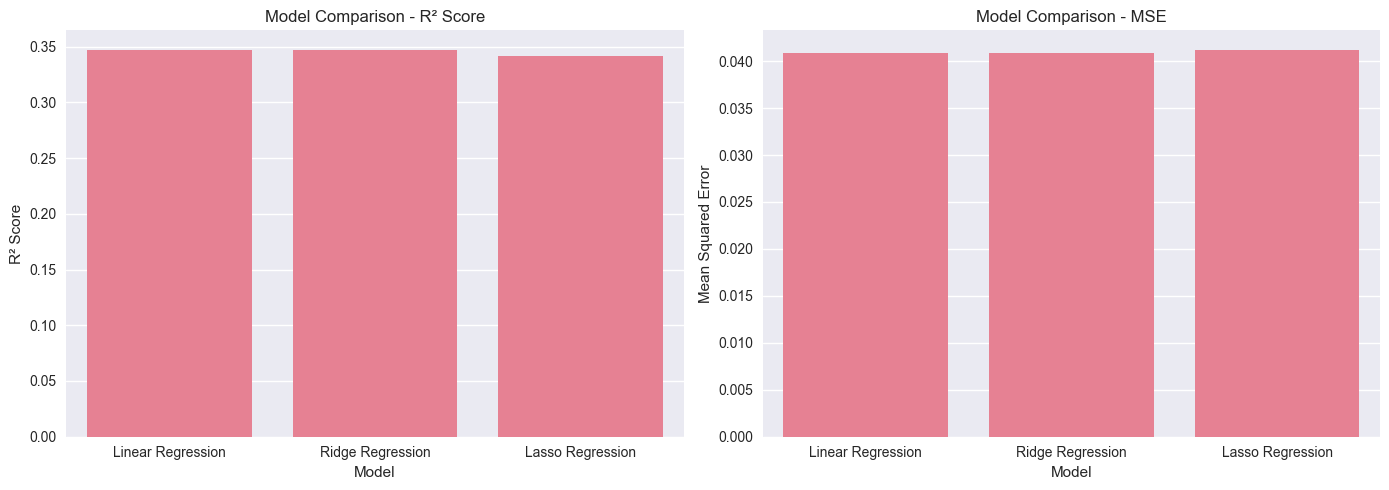

In [27]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Model', y='R²', data=model_comparison, ax=axes[0])
axes[0].set_title('Model Comparison - R² Score')
axes[0].set_ylabel('R² Score')

sns.barplot(x='Model', y='MSE', data=model_comparison, ax=axes[1])
axes[1].set_title('Model Comparison - MSE')
axes[1].set_ylabel('Mean Squared Error')

plt.tight_layout()
plt.show()

## 6. Residual Analysis

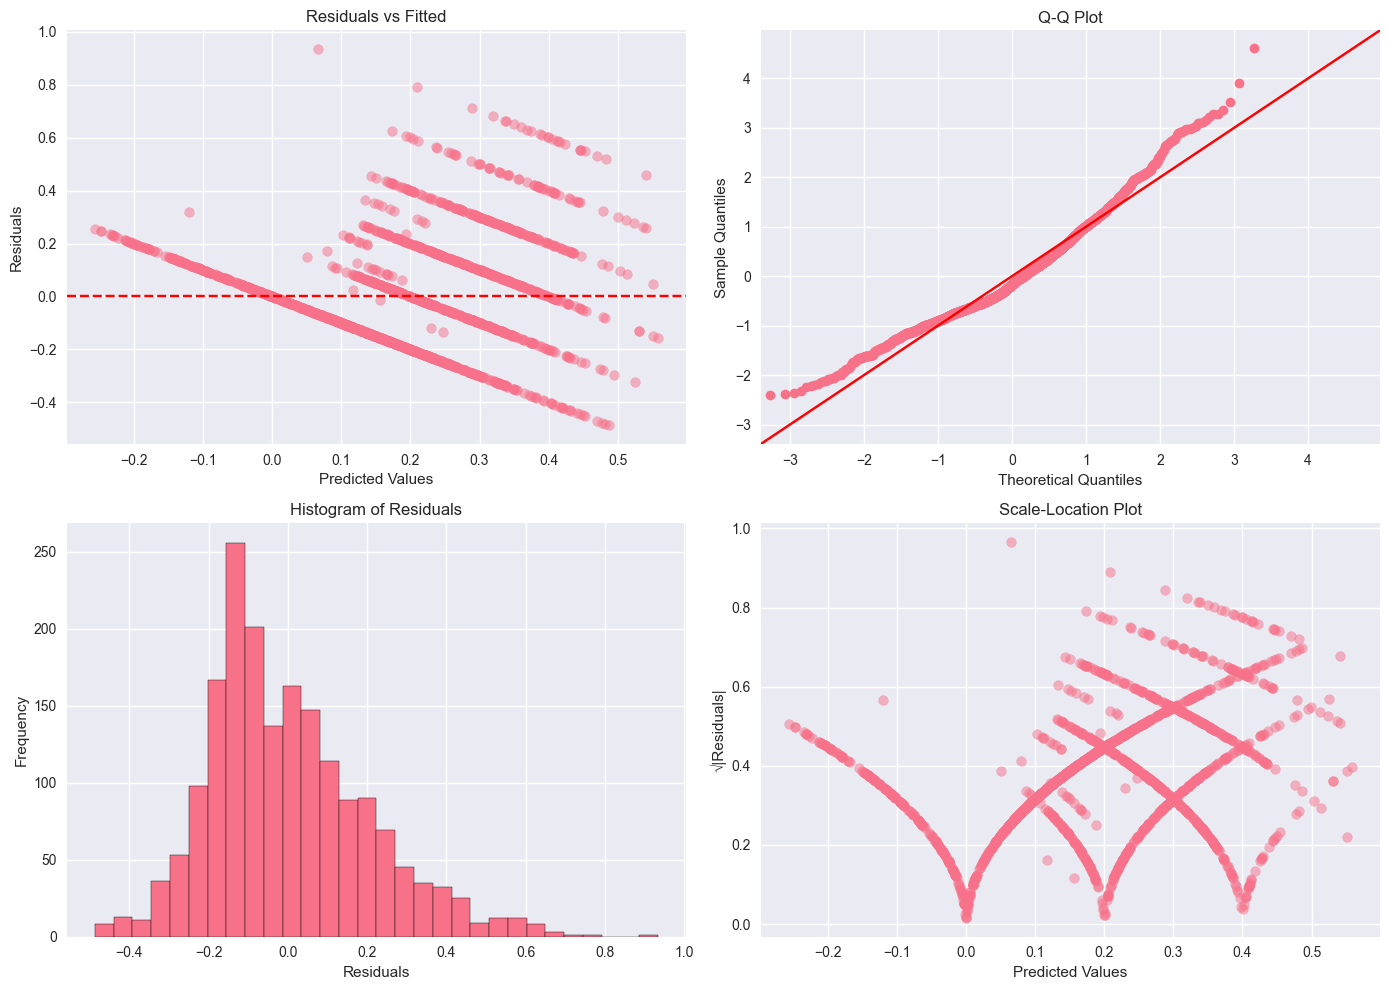

In [26]:
# Calculate residuals
residuals = y_test - y_test_pred

# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residual vs Fitted
axes[0, 0].scatter(y_test_pred, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# Q-Q plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')

# Histogram of residuals
axes[1, 0].hist(residuals, bins=30, edgecolor='black')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Histogram of Residuals')

# Scale-Location plot
axes[1, 1].scatter(y_test_pred, np.sqrt(np.abs(residuals)), alpha=0.5)
axes[1, 1].set_xlabel('Predicted Values')
axes[1, 1].set_ylabel('√|Residuals|')
axes[1, 1].set_title('Scale-Location Plot')

plt.tight_layout()
plt.show()

# LINEAR MODEL ANALYSIS SUMMARY

**Dataset Size:** 9180 samples, 16 features  
**Target Variable:** Divergence (mean = 0.1880, std = 0.2495)

**Best Model:** Linear Regression  
**Best R² Score:** 0.3472  
**Best MSE:** 0.0409

## Top 3 Most Important Features (by coefficient magnitude)
1. **months_since_post:** -0.0963
2. **log_comments:** 0.0889
3. **log_likes:** 0.0154

## Statistically Significant Features (p < 0.05)
- Intercept
- log_likes
- log_comments
- verified_encoded
- gender_match
- months_since_post